ahora veamos los circos de los dos sujetos

In [3]:
import pickle

with open("/kaggle/input/pesos-atencion/convex_kernel_v12p.pkl", "rb") as f:
    v12p = pickle.load(f)

with open("/kaggle/input/pesos-atencion/convex_kernel_v60p.pkl", "rb") as f:
    v60p  = pickle.load(f)

In [4]:
v12p.shape

(67, 19, 19, 1)

In [5]:
channels = ["Fz","Cz","Pz","C3","T3","C4","T4","Fp1","Fp2","F3","F4","F7","F8","P3","P4","T5","T6","O1","O2"]

areas = {
    'Frontal': ['Fz'],
    'Frontal Right': ['Fp2', 'F4', 'F8'],
    'Central \nRight': ['C4'],
    'Posterior Right': ['P4', 'O2'],
    'Posterior': ['Pz', 'Cz'],
    'Posterior Left': ['P3', 'O1'],
    'Central \nLeft': ['C3'],
    'Frontal Left': ['Fp1', 'F3', 'F7'],
    'Temporal Left': ['T3', 'T5'],
    'Temporal Right': ['T4', 'T6']
}

n_channels = len(channels)

In [6]:
pip install -U git+https://github.com/UN-GCPDS/python-gcpds.visualizations.git

  Cloning https://github.com/UN-GCPDS/python-gcpds.visualizations.git to /tmp/pip-req-build-w2tqpzfb
  Running command git clone --filter=blob:none --quiet https://github.com/UN-GCPDS/python-gcpds.visualizations.git /tmp/pip-req-build-w2tqpzfb
  Resolved https://github.com/UN-GCPDS/python-gcpds.visualizations.git to commit 162dbeac141a7472d3b0bd7f005932241b4663a5
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 72.1 MB/s eta 0:00:00
  Created wheel for gcpds-visualizations: filename=gcpds_visualizations-0.6-py3-none-any.whl size=12440 sha256=b8e6b61a695cff89f4eb54a2b505343fe3d199e84fb40e6c227c909a2fa5bd8c
  Stored in directory: /tmp/pip-ephem-wheel-cache-295pz92q/wheels/12/e9/11/f7246de13d1d668c154d68fb1260be82dbfbc166301807d756
Successfully built gcpds-visualizations
Note: you may need to restart the kernel to use updated packages.


In [7]:
from gcpds.visualizations.connectivities import CircosConnectivity
import matplotlib.pyplot as plt

def plot_circos(connectivities, eeg_ch_names, areas, threshold=0.6):
    """
    input
    connectivities: tensorflow square array
    """
    conn = CircosConnectivity(connectivities, eeg_ch_names, areas=areas, threshold=threshold,
    # cmaps and themes
    areas_cmap='PuRd',
    arcs_cmap='Wistia',
    hemisphere_color='lightgray',
    channel_color='#f8f9fa',
    min_alpha=0,
    # Texts
    width={'hemispheres':50, 'areas':100, 'channels':60},
    text={'hemispheres':40, 'areas':25,  'channels':40},
    separation={'hemispheres':10, 'areas':-30, 'channels':5},
    labelposition={'hemispheres':60, 'areas':-10, 'channels':-10},
    size=10,
    labelsize=17,
    # Shapes
    show_emisphere=True,
    arcs_separation=30,
    connection_width=0.1,
    small_separation=5,
    big_separation=10,
    offset=0,
    )

ADHD subejct


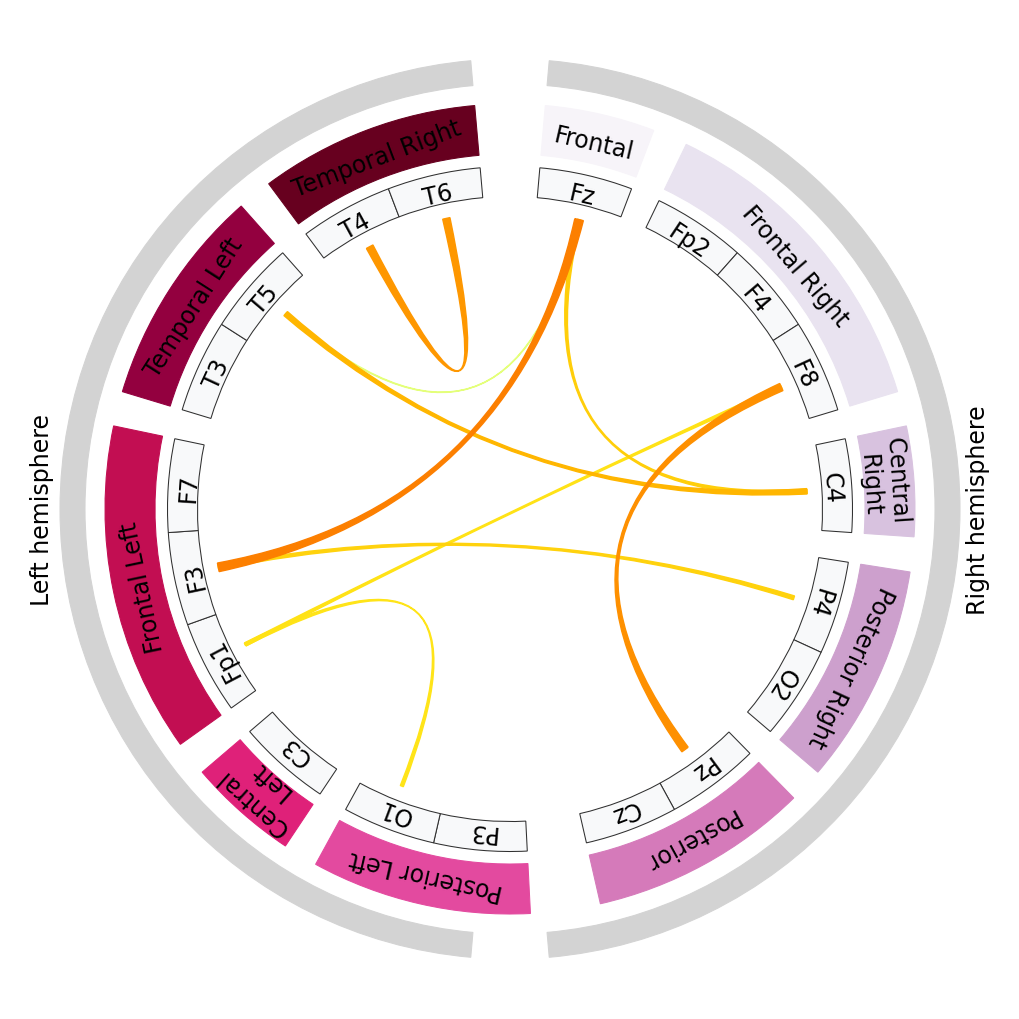

In [8]:
import numpy as np

print("ADHD subejct")
relations = np.mean(v12p, axis=(0,-1))
p90 = np.percentile(relations, 90)
plot_circos(relations, channels, areas, threshold=p90)
plt.savefig("circos_adhd_v270.pdf")
plt.show()

Control subejct


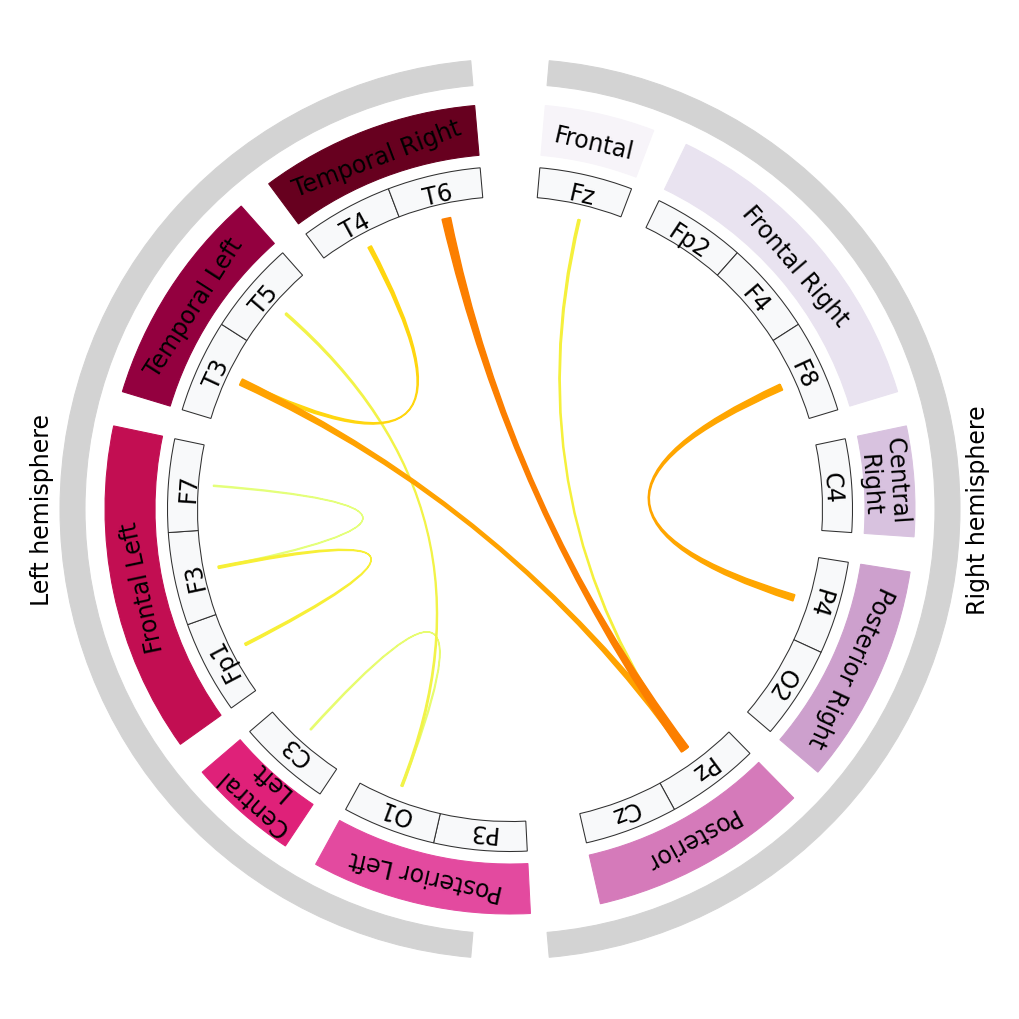

In [9]:
print("Control subejct")

relations = np.mean(v60p, axis=(0,-1))
p90 = np.percentile(relations, 90)
plot_circos(relations, channels, areas, threshold=p90)
plt.savefig("circos_control_v307.pdf")
plt.show()